# Sentiment Analysis on Flipkart Reviews
First, install all required packages (run this cell once).

In [44]:
!pip install pandas seaborn matplotlib nltk wordcloud scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\sk939\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## Import Libraries

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

## Load Dataset
Make sure `flipkart.csv` is in the same directory as this notebook.

In [46]:
data = pd.read_csv("flipkart.csv")
print(data.head())

   Unnamed: 0                                       Product_name  \
0           0  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
1           1  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
2           2  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
3           3  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   
4           4  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   

                                              Review  Rating  
0  Best under 60k Great performanceI got it for a...       5  
1                                 Good perfomence...       5  
2  Great performance but usually it has also that...       5  
3           My wife is so happy and best product 👌🏻😘       5  
4  Light weight laptop with new amazing features,...       5  


## Check for Missing Values

In [47]:
print(data.isnull().sum())

Unnamed: 0      0
Product_name    0
Review          0
Rating          0
dtype: int64


## Text Preprocessing Setup

In [48]:
import nltk
import re
nltk.download("stopwords")
stemmer = nltk.SnowballStemmer("english")
from nltk.corpus import stopwords
import string
stopword = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sk939\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Clean Review Text

In [49]:
def clean(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = [word for word in text.split(' ') if word not in stopword]
    text = " ".join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text = " ".join(text)
    return text

data["Review"] = data["Review"].apply(clean)

## Rating Distribution (Pie Chart)

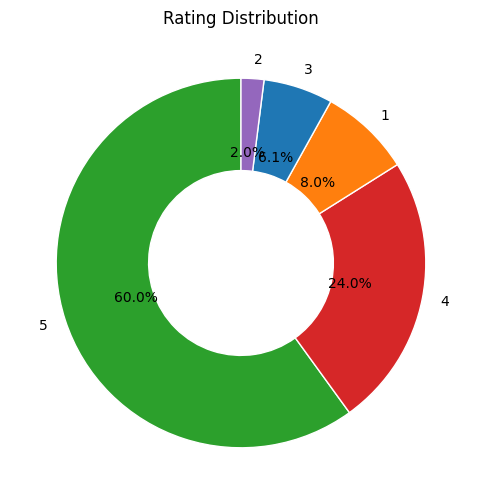

In [50]:
ratings = data["Rating"].value_counts()
numbers = ratings.index
quantity = ratings.values

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.pie(quantity, labels=numbers, autopct='%1.1f%%', startangle=90,
        colors=['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4', '#9467bd'],
        wedgeprops={'width': 0.5, 'edgecolor': 'white'})
plt.title("Rating Distribution")
plt.show()

## Word Cloud Visualization

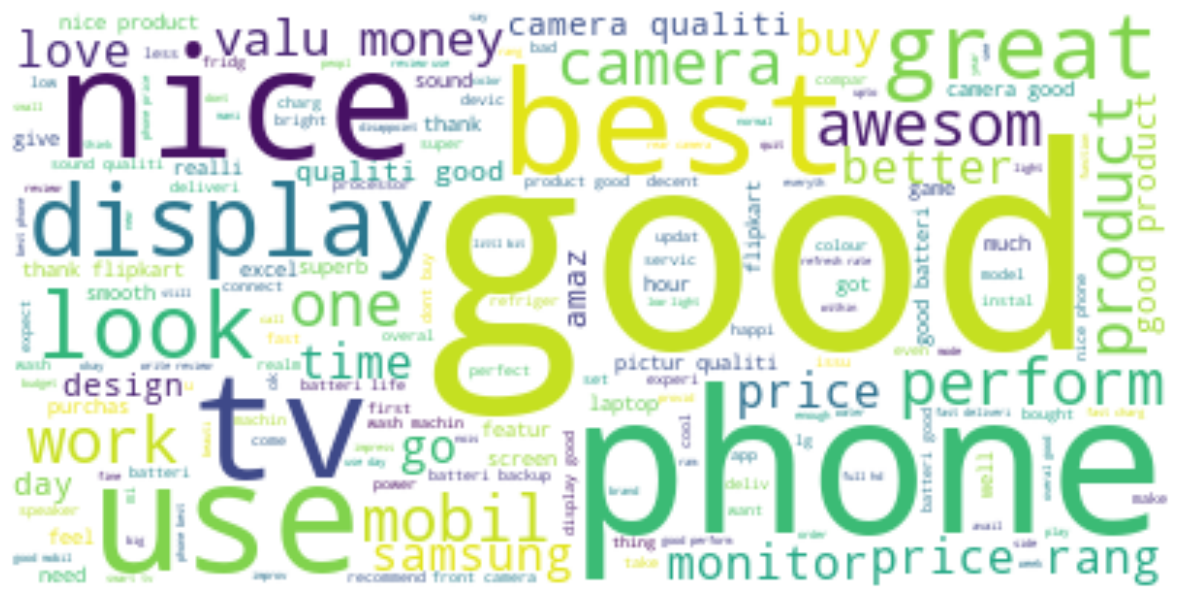

In [51]:
text = " ".join(i for i in data.Review)
wc_stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=wc_stopwords, background_color="white").generate(text)
plt.figure(figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## Sentiment Analysis with VADER

In [52]:
nltk.download('vader_lexicon')
sentiments = SentimentIntensityAnalyzer()
data["Positive"] = [sentiments.polarity_scores(i)["pos"] for i in data["Review"]]
data["Negative"] = [sentiments.polarity_scores(i)["neg"] for i in data["Review"]]
data["Neutral"] = [sentiments.polarity_scores(i)["neu"] for i in data["Review"]]
sentiment_data = data[["Review", "Positive", "Negative", "Neutral"]]
print(sentiment_data.head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sk939\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                              Review  Positive  Negative  \
0  best  great performancei got around  backup bi...     0.395     0.101   
1                                        good perfom     0.744     0.000   
2  great perform usual also game laptop issu batt...     0.277     0.000   
3                        wife happi best product 👌🏻😘     0.512     0.000   
4  light weight laptop new amaz featur batteri li...     0.000     0.000   

   Neutral  
0    0.504  
1    0.256  
2    0.723  
3    0.488  
4    1.000  


## Overall Sentiment Score

In [53]:
x = sum(sentiment_data["Positive"])
y = sum(sentiment_data["Negative"])
z = sum(sentiment_data["Neutral"])

def sentiment_score(a, b, c):
    if (a>b) and (a>c):
        print("Positive")
    elif (b>a) and (b>c):
        print("Negative")
    else:
        print("Neutral")
sentiment_score(x, y, z)

Neutral


## Sentiment Score Values

In [54]:
print("Positive: ", x)
print("Negative: ", y)
print("Neutral: ", z)

Positive:  923.553
Negative:  96.775
Neutral:  1283.688


## Model Accuracy and Evaluation
Here we compare the unsupervised VADER predicted sentiment against the true sentiment derived from customer ratings.

In [55]:
# Map numerical ratings to sentiment categories
def get_true_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

data["True_Sentiment"] = data["Rating"].apply(get_true_sentiment)

# Calculate VADER compound score for each review
data["Compound"] = [sentiments.polarity_scores(i)["compound"] for i in data["Review"]]

# Map VADER compound score to sentiment categories
def get_predicted_sentiment(compound):
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

data["Predicted_Sentiment"] = data["Compound"].apply(get_predicted_sentiment)

# Evaluate accuracy
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(data["True_Sentiment"], data["Predicted_Sentiment"])
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(data["True_Sentiment"], data["Predicted_Sentiment"]))


Accuracy Score: 82.64%

Classification Report:
               precision    recall  f1-score   support

    Negative       0.73      0.49      0.59       230
     Neutral       0.11      0.14      0.12       140
    Positive       0.90      0.92      0.91      1934

    accuracy                           0.83      2304
   macro avg       0.58      0.52      0.54      2304
weighted avg       0.83      0.83      0.83      2304

